<a href="https://colab.research.google.com/github/Kavin1997-hub/Diamond_Dynamics/blob/main/Diamond_Dynamics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Setup & Import Libraries

In [1]:
# Basic libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor

# Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Clustering
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings('ignore')

2. Loading Dataset

In [8]:
# Upload CSV manually in Colab
from google.colab import files

df = pd.read_csv("/content/diamonds.csv")
df

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...
53935,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74


3. Basic Data Check

In [9]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  object 
 2   color    53940 non-null  object 
 3   clarity  53940 non-null  object 
 4   depth    53940 non-null  float64
 5   table    53940 non-null  float64
 6   price    53940 non-null  int64  
 7   x        53940 non-null  float64
 8   y        53940 non-null  float64
 9   z        53940 non-null  float64
dtypes: float64(6), int64(1), object(3)
memory usage: 4.1+ MB


,0
carat,0
cut,0
color,0
clarity,0
depth,0
table,0
price,0
x,0
y,0
z,0


4. Data Cleaning

In [10]:
# Remove invalid values (x, y, z cannot be 0)
df = df[(df['x'] > 0) & (df['y'] > 0) & (df['z'] > 0)]

# Reset index
df.reset_index(drop=True, inplace=True)

5. Outlier Removal (IQR)

In [11]:
def remove_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    return df[(df[col] >= Q1 - 1.5*IQR) & (df[col] <= Q3 + 1.5*IQR)]

for col in ['carat', 'price', 'x', 'y', 'z']:
    df = remove_outliers(df, col)

6. EDA (Quick Visuals)

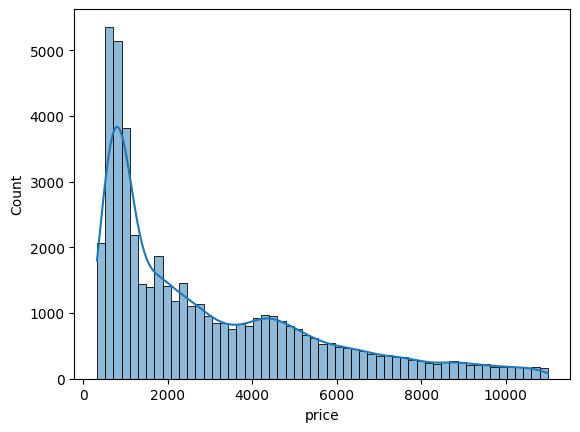

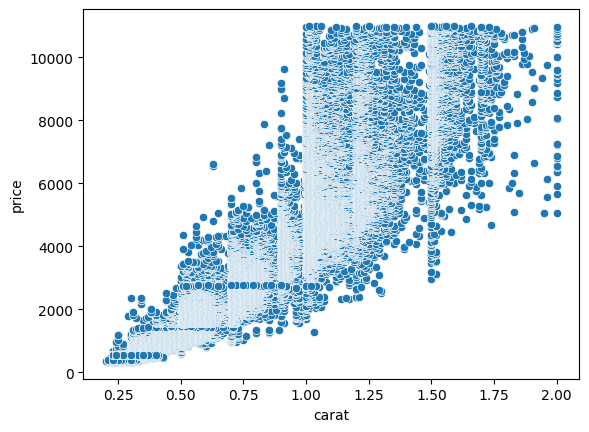

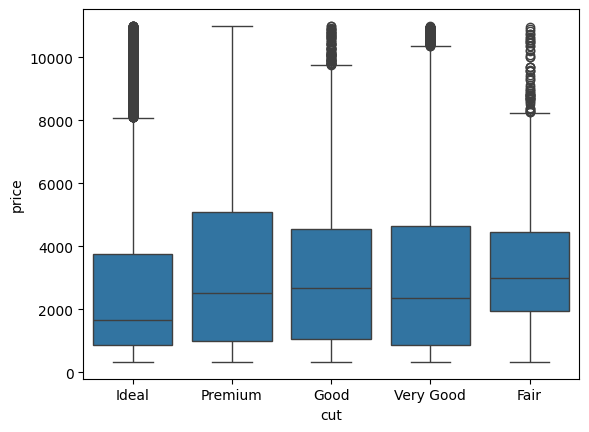

In [12]:
sns.histplot(df['price'], kde=True)
plt.show()

sns.scatterplot(x='carat', y='price', data=df)
plt.show()

sns.boxplot(x='cut', y='price', data=df)
plt.show()

7. Feature Engineering

In [13]:
# New features
df['volume'] = df['x'] * df['y'] * df['z']
df['price_per_carat'] = df['price'] / df['carat']
df['dimension_ratio'] = (df['x'] + df['y']) / (2 * df['z'])

# Convert USD to INR (example rate)
df['price_inr'] = df['price'] * 83

8. Encoding Categorical Features

In [14]:
le = LabelEncoder()

for col in ['cut', 'color', 'clarity']:
    df[col] = le.fit_transform(df[col])

9. Train-Test Split

In [15]:
X = df.drop(['price', 'price_inr'], axis=1)
y = df['price_inr']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

10. Scaling

In [16]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

11. Train Models

In [17]:
models = {
    "Linear": LinearRegression(),
    "Random Forest": RandomForestRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "KNN": KNeighborsRegressor()
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results[name] = {
        "MAE": mean_absolute_error(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "R2": r2_score(y_test, y_pred)
    }

results

{'Linear': {'MAE': 18494.624175306133,
  'RMSE': np.float64(25809.245491548365),
  'R2': 0.9853253481618527},
 'Random Forest': {'MAE': 980.9440515151516,
  'RMSE': np.float64(3442.8426795024056),
  'R2': 0.9997388731406827},
 'Decision Tree': {'MAE': 1765.7118181818182,
  'RMSE': np.float64(5854.203371514394),
  'R2': 0.9992449898326153},
 'KNN': {'MAE': 12925.184222222224,
  'RMSE': np.float64(20811.000322365355),
  'R2': 0.9904587977695195}}

12. ANN Model (TensorFlow)

In [18]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')

model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2)

y_pred_ann = model.predict(X_test)

print("ANN RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_ann)))

Epoch 1/20
990/990 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 103368990720.0000 - val_loss: 87740383232.0000
Epoch 2/20
990/990 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 56763318272.0000 - val_loss: 25821589504.0000
Epoch 3/20
990/990 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 12729469952.0000 - val_loss: 6890657280.0000
Epoch 4/20
990/990 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 5546381824.0000 - val_loss: 4555210752.0000
Epoch 5/20
990/990 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 3670249984.0000 - val_loss: 3041003776.0000
Epoch 6/20
990/990 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 2518061056.0000 - val_loss: 2164100864.0000
Epoch 7/20
990/990 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 1811154304.0000 - val_loss: 1560761856.0000
Epoch 8/20
990/990 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1310091776.0000 - val_loss: 1142233856.0000
Epoch 9/20
990/990 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 984035712.0000 - val_loss: 889989888.0000
Epoch 10/20
990/990 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss:

13. Clustering (K-Means)

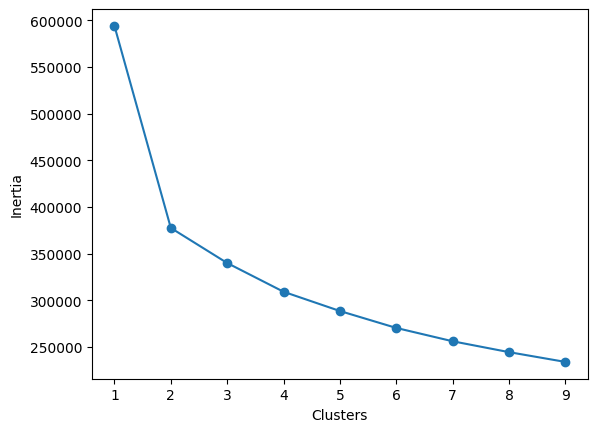

In [19]:
# Remove price columns for clustering
cluster_df = df.drop(['price', 'price_inr'], axis=1)

# Scale
scaler = StandardScaler()
cluster_scaled = scaler.fit_transform(cluster_df)

# Elbow Method
inertia = []
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(cluster_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 10), inertia, marker='o')
plt.xlabel("Clusters")
plt.ylabel("Inertia")
plt.show()

14. Apply K-Means

In [20]:
kmeans = KMeans(n_clusters=3)
df['cluster'] = kmeans.fit_predict(cluster_scaled)

df.head(50)

,carat,cut,color,clarity,depth,table,price,x,y,z,volume,price_per_carat,dimension_ratio,price_inr,cluster
0,0.23,2,1,3,61.5,55.0,326,3.95,3.98,2.43,38.202030,1417.391304,1.631687,27058,1
1,0.21,3,1,2,59.8,61.0,326,3.89,3.84,2.31,34.505856,1552.380952,1.673160,27058,1
2,0.23,1,1,4,56.9,65.0,327,4.05,4.07,2.31,38.076885,1421.739130,1.757576,27141,1
3,0.29,3,5,5,62.4,58.0,334,4.20,4.23,2.63,46.724580,1151.724138,1.602662,27722,1
4,0.31,1,6,3,63.3,58.0,335,4.34,4.35,2.75,51.917250,1080.645161,1.580000,27805,1
5,0.24,4,6,7,62.8,57.0,336,3.94,3.96,2.48,38.693952,1400.000000,1.592742,27888,1
6,0.24,4,5,6,62.3,57.0,336,3.95,3.98,2.47,38.830870,1400.000000,1.605263,27888,1
7,0.26,4,4,2,61.9,55.0,337,4.07,4.11,2.53,42.321081,1296.153846,1.616601,27971,1
8,0.22,0,1,5,65.1,61.0,337,3.87,3.78,2.49,36.425214,1531.818182,1.536145,27971,1
9,0.23,4,4,4,59.4,61.0,338,4.00,4.05,2.39,38.718000,1469.565217,1.684100,28054,1


15. PCA Visualization

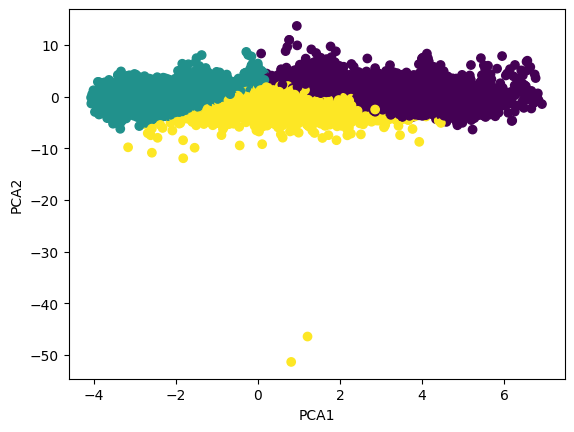

In [21]:
pca = PCA(n_components=2)
pca_data = pca.fit_transform(cluster_scaled)

plt.scatter(pca_data[:,0], pca_data[:,1], c=df['cluster'])
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.show()

16. Save Model

In [22]:
import pickle

with open("model.pkl", "wb") as f:
    pickle.dump(models["Random Forest"], f)

In [24]:
import pickle

pickle.dump(scaler, open("scaler.pkl", "wb"))

In [26]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 64.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 65.8 MB/s eta 0:00:00


In [28]:
!pip install streamlit
!npm install localtunnel

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴
added 22 packages in 3s
⠴
⠴3 packages are looking for funding
⠴  run `npm fund` for details
⠴

In [38]:
%%writefile app.py
# paste your full Streamlit code here

Overwriting app.py


In [36]:
!streamlit run app.py &>/content/logs.txt &

In [33]:
scaler.n_features_in_

12

In [34]:
print(X.columns)

Index(['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'x', 'y', 'z',
       'volume', 'price_per_carat', 'dimension_ratio'],
      dtype='object')


In [45]:
import streamlit as st
import numpy as np
import pickle

# ------------------ LOAD MODELS ------------------
model = pickle.load(open("model.pkl", "rb"))
scaler = pickle.load(open("scaler.pkl", "rb"))

# Optional clustering
try:
    kmeans = pickle.load(open("kmeans.pkl", "rb"))
except:
    kmeans = None

# ------------------ TITLE ------------------
st.title("💎 Diamond Price Prediction & Segmentation")

st.markdown("Enter diamond details to predict price and category")

# ------------------ INPUTS ------------------
st.sidebar.header("Diamond Features")

carat = st.sidebar.number_input("Carat", 0.1, 5.0, 0.5)

cut = st.sidebar.selectbox("Cut", ["Fair", "Good", "Very Good", "Premium", "Ideal"])
color = st.sidebar.selectbox("Color", ["D", "E", "F", "G", "H", "I", "J"])
clarity = st.sidebar.selectbox("Clarity", ["IF", "VVS1", "VVS2", "VS1", "VS2", "SI1", "SI2", "I1"])

depth = st.sidebar.number_input("Depth", 40.0, 80.0, 60.0)
table = st.sidebar.number_input("Table", 40.0, 80.0, 55.0)

x = st.sidebar.number_input("Length (x)", 1.0, 10.0, 5.0)
y = st.sidebar.number_input("Width (y)", 1.0, 10.0, 5.0)
z = st.sidebar.number_input("Depth (z)", 1.0, 10.0, 3.0)

# ------------------ ENCODING ------------------
cut_map = {"Fair":0, "Good":1, "Very Good":2, "Premium":3, "Ideal":4}
color_map = {"D":0, "E":1, "F":2, "G":3, "H":4, "I":5, "J":6}
clarity_map = {"IF":0, "VVS1":1, "VVS2":2, "VS1":3, "VS2":4, "SI1":5, "SI2":6, "I1":7}

cut = cut_map[cut]
color = color_map[color]
clarity = clarity_map[clarity]

# ------------------ FEATURE ENGINEERING ------------------
volume = x * y * z
dimension_ratio = (x + y) / (2 * z)

# IMPORTANT: must match training columns EXACTLY
features = np.array([[
    carat,
    cut,
    color,
    clarity,
    depth,
    table,
    x,
    y,
    z,
    volume,
    dimension_ratio
]])

# ------------------ SCALING ------------------
try:
    features_scaled = scaler.transform(features)
except Exception as e:
    st.error(f"Scaler error: {e}")
    st.stop()

# ------------------ PREDICTION ------------------
if st.button("Predict Price 💰"):
    try:
        prediction = model.predict(features_scaled)
        st.success(f"💰 Estimated Price: ₹ {int(prediction[0])}")
    except Exception as e:
        st.error(f"Prediction error: {e}")

# ------------------ CLUSTERING ------------------
if kmeans is not None:
    if st.button("Predict Category 📊"):
        try:
            cluster = kmeans.predict(features_scaled)[0]

            cluster_names = {
                0: "💎 Affordable Small Diamonds",
                1: "💎 Mid-range Balanced Diamonds",
                2: "💎 Premium Heavy Diamonds"
            }

            st.info(f"Cluster: {cluster_names.get(cluster, 'Unknown')}")
        except Exception as e:
            st.error(f"Clustering error: {e}")

# ------------------ DEBUG (OPTIONAL) ------------------
with st.expander("Debug Info"):
    st.write("Feature Shape:", features.shape)
    st.write("Features:", features)

2026-04-29 06:37:16.848 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-29 06:37:16.849 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-29 06:37:16.851 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-29 06:37:16.853 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-29 06:37:16.853 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-29 06:37:16.854 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-29 06:37:16.855 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-29 06:37:16.857 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar